# Chapter 74 — Debugging GPT Training

The previous chapters built, trained, and sampled from a tiny GPT.

This chapter develops a repeatable process for finding training failures before scaling an experiment.

## Learning goals

By the end of this chapter, you will be able to:

- verify input, target, and logit shapes;
- validate token dtypes, ranges, and the next-token shift;
- check parameter counts and architecture boundaries;
- detect non-finite losses, logits, and gradients;
- interpret per-parameter and total gradient norms;
- use gradient clipping without treating it as a bug fix;
- run a tiny-batch overfit test;
- distinguish flat, unstable, and overfitting loss curves; and
- debug one hypothesis at a time.

## Start from invariants

An **invariant** is a condition that must remain true for a particular training design.

For the contiguous GPT batches used in this course, the core invariants are:

- inputs and targets are rank-two `torch.long` tensors with equal shapes;
- `targets[:, :-1]` equals `inputs[:, 1:]`;
- logits have shape `[batch, context, vocabulary]`;
- every target ID is in `[0, vocabulary_size)`;
- the causal mask blocks future positions;
- loss, logits, and gradients are finite; and
- an optimizer update changes trainable parameters.

A failed invariant is evidence.

Changing model size, optimizer, data, and decoding simultaneously destroys evidence about which change mattered.

## A diagnostic order

Use cheap, local checks before a long run:

1. Decode a batch and verify its shift.
2. Check dtypes, ranges, and shapes.
3. Run one forward pass and check finite logits and loss.
4. Run one backward pass and inspect gradients.
5. Confirm that an optimizer step changes parameters.
6. Try to overfit one fixed tiny batch.
7. Only then inspect longer-run validation behavior and generation.

## Build a deterministic debugging fixture

A **debugging fixture** is a small, repeatable setup used to isolate behavior.

This fixture uses a character vocabulary, two contiguous rows, and context length `8`.

In [1]:
import torch

device = "cpu"
debug_text = ("the cat sat on the mat.\n" * 8).strip()
characters = sorted(set(debug_text))
character_to_id = {
    character: character_id for character_id, character in enumerate(characters)
}
id_to_character = {
    character_id: character for character, character_id in character_to_id.items()
}
all_token_ids = torch.tensor(
    [character_to_id[character] for character in debug_text],
    dtype=torch.long,
    device=device,
)
context_length = 8
start_indexes = [0, 4]
input_token_ids = torch.stack(
    [all_token_ids[start : start + context_length] for start in start_indexes]
)
target_token_ids = torch.stack(
    [all_token_ids[start + 1 : start + context_length + 1] for start in start_indexes]
)
vocabulary_size = len(characters)

print("device:", device)
print("vocabulary:", characters)
print("input shape:", input_token_ids.shape)
print("target shape:", target_token_ids.shape)
for row_index in range(input_token_ids.shape[0]):
    decoded_input = "".join(
        id_to_character[token_id] for token_id in input_token_ids[row_index].tolist()
    )
    decoded_target = "".join(
        id_to_character[token_id] for token_id in target_token_ids[row_index].tolist()
    )
    print(f"row {row_index}: {decoded_input!r} -> {decoded_target!r}")

device: cpu
vocabulary: ['\n', ' ', '.', 'a', 'c', 'e', 'h', 'm', 'n', 'o', 's', 't']
input shape: torch.Size([2, 8])
target shape: torch.Size([2, 8])
row 0: 'the cat ' -> 'he cat s'
row 1: 'cat sat ' -> 'at sat o'


## Define a small causal GPT

The model uses the same pre-normalized residual structure as earlier chapters but only one block and `16` embedding dimensions.

Dropout is zero so repeated diagnostic passes are deterministic.

In [2]:
import math


class DebugCausalSelfAttention(torch.nn.Module):
    """Compute combined-head causal self-attention for debugging."""

    embedding_dimension: int
    number_of_heads: int
    head_size: int
    query: torch.nn.Linear
    key: torch.nn.Linear
    value: torch.nn.Linear
    output: torch.nn.Linear
    causal_mask: torch.Tensor

    def __init__(
        self, embedding_dimension: int, number_of_heads: int, context_length: int
    ) -> None:
        super().__init__()
        if embedding_dimension % number_of_heads != 0:
            raise ValueError("embedding dimension must divide by head count.")
        self.embedding_dimension = embedding_dimension
        self.number_of_heads = number_of_heads
        self.head_size = embedding_dimension // number_of_heads
        self.query = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.key = torch.nn.Linear(embedding_dimension, embedding_dimension, bias=False)
        self.value = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.output = torch.nn.Linear(embedding_dimension, embedding_dimension)
        self.register_buffer(
            "causal_mask",
            torch.tril(
                torch.ones(1, 1, context_length, context_length, dtype=torch.bool)
            ),
        )

    def _split_heads(self, values: torch.Tensor) -> torch.Tensor:
        batch_size, sequence_length, _ = values.shape
        return values.reshape(
            batch_size, sequence_length, self.number_of_heads, self.head_size
        ).transpose(1, 2)

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        batch_size, sequence_length, _ = input_values.shape
        queries = self._split_heads(self.query(input_values))
        keys = self._split_heads(self.key(input_values))
        values = self._split_heads(self.value(input_values))
        scores = (queries @ keys.transpose(-2, -1)) / math.sqrt(self.head_size)
        allowed = self.causal_mask[:, :, :sequence_length, :sequence_length]
        weights = torch.softmax(scores.masked_fill(~allowed, float("-inf")), dim=-1)
        attended = weights @ values
        combined = attended.transpose(1, 2).reshape(
            batch_size, sequence_length, self.embedding_dimension
        )
        return self.output(combined)


class DebugTransformerBlock(torch.nn.Module):
    """Apply one pre-normalized attention and feedforward block."""

    first_norm: torch.nn.LayerNorm
    attention: DebugCausalSelfAttention
    second_norm: torch.nn.LayerNorm
    feedforward: torch.nn.Sequential

    def __init__(
        self, embedding_dimension: int, number_of_heads: int, context_length: int
    ) -> None:
        super().__init__()
        self.first_norm = torch.nn.LayerNorm(embedding_dimension)
        self.attention = DebugCausalSelfAttention(
            embedding_dimension, number_of_heads, context_length
        )
        self.second_norm = torch.nn.LayerNorm(embedding_dimension)
        self.feedforward = torch.nn.Sequential(
            torch.nn.Linear(embedding_dimension, 4 * embedding_dimension),
            torch.nn.ReLU(),
            torch.nn.Linear(4 * embedding_dimension, embedding_dimension),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        after_attention = input_values + self.attention(self.first_norm(input_values))
        return after_attention + self.feedforward(self.second_norm(after_attention))


class DebugTinyGPT(torch.nn.Module):
    """Map token IDs to vocabulary logits and optional next-token loss."""

    vocabulary_size: int
    context_length: int
    token_embedding: torch.nn.Embedding
    position_embedding: torch.nn.Embedding
    block: DebugTransformerBlock
    final_norm: torch.nn.LayerNorm
    output_layer: torch.nn.Linear

    def __init__(
        self, vocabulary_size: int, context_length: int, embedding_dimension: int
    ) -> None:
        super().__init__()
        self.vocabulary_size = vocabulary_size
        self.context_length = context_length
        self.token_embedding = torch.nn.Embedding(vocabulary_size, embedding_dimension)
        self.position_embedding = torch.nn.Embedding(
            context_length, embedding_dimension
        )
        self.block = DebugTransformerBlock(
            embedding_dimension, number_of_heads=4, context_length=context_length
        )
        self.final_norm = torch.nn.LayerNorm(embedding_dimension)
        self.output_layer = torch.nn.Linear(embedding_dimension, vocabulary_size)

    def forward(
        self,
        input_ids: torch.Tensor,
        target_ids: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        if input_ids.ndim != 2:
            raise ValueError("input IDs must have shape [batch, context].")
        sequence_length = input_ids.shape[1]
        if not 1 <= sequence_length <= self.context_length:
            raise ValueError("input length must be within the model context limit.")
        positions = torch.arange(sequence_length, device=input_ids.device)
        values = self.token_embedding(input_ids) + self.position_embedding(positions)
        logits = self.output_layer(self.final_norm(self.block(values)))
        loss = None
        if target_ids is not None:
            if target_ids.shape != input_ids.shape:
                raise ValueError("targets must have the same shape as inputs.")
            loss = torch.nn.functional.cross_entropy(
                logits.reshape(-1, self.vocabulary_size), target_ids.reshape(-1)
            )
        return logits, loss


torch.manual_seed(74)
model = DebugTinyGPT(
    vocabulary_size=vocabulary_size,
    context_length=context_length,
    embedding_dimension=16,
).to(device)
logits, initial_loss = model(input_token_ids, target_token_ids)
print("logit shape:", logits.shape)
print("initial loss:", initial_loss.item())

logit shape: torch.Size([2, 8, 12])
initial loss: 2.8089630603790283


## Write reusable invariant checks

Each helper raises close to the source of a problem and includes the observed value in its message.

The gradient summary distinguishes missing gradients from non-finite gradients because they suggest different failures.

In [3]:
from typing import NamedTuple


class GradientSummary(NamedTuple):
    """Summarize gradient magnitude and availability."""

    total_norm: float
    parameters_with_gradients: int
    missing_gradient_names: list[str]
    nonfinite_gradient_names: list[str]


def check_input_target_invariants(
    input_ids: torch.Tensor, target_ids: torch.Tensor
) -> None:
    if input_ids.ndim != 2 or target_ids.ndim != 2:
        raise ValueError(
            "inputs and targets must both have shape [batch, context]; "
            f"got {tuple(input_ids.shape)} and {tuple(target_ids.shape)}."
        )
    if input_ids.shape != target_ids.shape:
        raise ValueError(
            f"input shape {tuple(input_ids.shape)} does not match "
            f"target shape {tuple(target_ids.shape)}."
        )
    if input_ids.dtype != torch.long or target_ids.dtype != torch.long:
        raise TypeError(
            f"inputs and targets must be torch.long; got {input_ids.dtype} "
            f"and {target_ids.dtype}."
        )
    if input_ids.numel() == 0:
        raise ValueError("inputs and targets must not be empty.")


def check_token_range(token_ids: torch.Tensor, vocabulary_size: int) -> None:
    smallest_id = token_ids.min().item()
    largest_id = token_ids.max().item()
    if smallest_id < 0 or largest_id >= vocabulary_size:
        raise ValueError(
            f"token IDs must be in [0, {vocabulary_size}); "
            f"observed minimum {smallest_id} and maximum {largest_id}."
        )


def check_contiguous_gpt_shift(
    input_ids: torch.Tensor, target_ids: torch.Tensor
) -> None:
    check_input_target_invariants(input_ids, target_ids)
    if not torch.equal(target_ids[:, :-1], input_ids[:, 1:]):
        raise ValueError(
            "target[:, :-1] must equal input[:, 1:] for contiguous GPT rows."
        )


def check_logit_invariants(
    logits: torch.Tensor, input_ids: torch.Tensor, vocabulary_size: int
) -> None:
    expected_shape = (*input_ids.shape, vocabulary_size)
    if logits.shape != expected_shape:
        raise ValueError(
            f"expected logit shape {expected_shape}, got {tuple(logits.shape)}."
        )
    if not torch.isfinite(logits).all().item():
        raise FloatingPointError("logits contain nan or infinity.")


def check_finite_loss(loss: torch.Tensor | None) -> None:
    if loss is None:
        raise ValueError("loss is None because targets were not supplied.")
    if not torch.isfinite(loss).item():
        raise FloatingPointError(f"loss is not finite: {loss.item()}.")


def count_parameters(module: torch.nn.Module) -> int:
    return sum(parameter.numel() for parameter in module.parameters())


def summarize_gradients(module: torch.nn.Module) -> GradientSummary:
    squared_norm = 0.0
    parameters_with_gradients = 0
    missing_names = []
    nonfinite_names = []
    for name, parameter in module.named_parameters():
        if parameter.grad is None:
            missing_names.append(name)
            continue
        parameters_with_gradients += 1
        gradient = parameter.grad.detach().float()
        if not torch.isfinite(gradient).all().item():
            nonfinite_names.append(name)
        squared_norm += gradient.square().sum().item()

    return GradientSummary(
        total_norm=squared_norm**0.5,
        parameters_with_gradients=parameters_with_gradients,
        missing_gradient_names=missing_names,
        nonfinite_gradient_names=nonfinite_names,
    )

## Diagnose one healthy batch

The first serious test performs one forward and backward pass without updating parameters.

A nonzero total norm and an empty non-finite list show that gradient information reached the model.

In [4]:
check_input_target_invariants(input_token_ids, target_token_ids)
check_token_range(input_token_ids, vocabulary_size)
check_token_range(target_token_ids, vocabulary_size)
check_contiguous_gpt_shift(input_token_ids, target_token_ids)
logits, loss = model(input_token_ids, target_token_ids)
check_logit_invariants(logits, input_token_ids, vocabulary_size)
check_finite_loss(loss)

model.zero_grad(set_to_none=True)
loss.backward()
gradient_summary = summarize_gradients(model)

print("parameter count:", count_parameters(model))
print("input shape:", tuple(input_token_ids.shape))
print("target shape:", tuple(target_token_ids.shape))
print("logit shape:", tuple(logits.shape))
print("loss:", loss.item())
print("total gradient norm:", gradient_summary.total_norm)
print("parameters with gradients:", end=" ")
print(gradient_summary.parameters_with_gradients)
print("missing gradients:", gradient_summary.missing_gradient_names)
print("non-finite gradients:", gradient_summary.nonfinite_gradient_names)
print()
print("first eight parameter gradient norms:")
for parameter_index, (name, parameter) in enumerate(model.named_parameters()):
    if parameter_index >= 8:
        break
    gradient_norm = None if parameter.grad is None else parameter.grad.norm().item()
    print(f"{name:<42} {gradient_norm}")

parameter count: 3788
input shape: (2, 8)
target shape: (2, 8)
logit shape: (2, 8, 12)
loss: 2.8089630603790283
total gradient norm: 1.4493341089334397
parameters with gradients: 19
missing gradients: []
non-finite gradients: []

first eight parameter gradient norms:
token_embedding.weight                     0.1312185376882553
position_embedding.weight                  0.10938724875450134
block.first_norm.weight                    0.020190207287669182
block.first_norm.bias                      0.04290138930082321
block.attention.query.weight               0.03492506965994835
block.attention.key.weight                 0.027326565235853195
block.attention.value.weight               0.12692780792713165
block.attention.output.weight              0.12263156473636627


## Make common failures explicit

The next examples deliberately violate one invariant at a time and catch the expected exception.

These are diagnostic demonstrations, not failed notebook cells.

In [5]:
wrong_shape_targets = target_token_ids[:, :-1]
wrong_dtype_targets = target_token_ids.float()
out_of_range_targets = target_token_ids.clone()
out_of_range_targets[0, 0] = vocabulary_size
broken_shift_targets = target_token_ids.clone()
broken_shift_targets[0, 0] = (broken_shift_targets[0, 0] + 1) % vocabulary_size
wrong_shape_logits = logits[:, :-1, :]
nonfinite_logits = logits.clone()
nonfinite_logits[0, 0, 0] = float("nan")

failure_checks = [
    (
        "shape mismatch",
        lambda: check_input_target_invariants(input_token_ids, wrong_shape_targets),
    ),
    (
        "wrong target dtype",
        lambda: check_input_target_invariants(input_token_ids, wrong_dtype_targets),
    ),
    (
        "out-of-range target",
        lambda: check_token_range(out_of_range_targets, vocabulary_size),
    ),
    (
        "broken shift",
        lambda: check_contiguous_gpt_shift(input_token_ids, broken_shift_targets),
    ),
    (
        "wrong logit shape",
        lambda: check_logit_invariants(
            wrong_shape_logits, input_token_ids, vocabulary_size
        ),
    ),
    (
        "non-finite logits",
        lambda: check_logit_invariants(
            nonfinite_logits, input_token_ids, vocabulary_size
        ),
    ),
]

for failure_name, run_check in failure_checks:
    try:
        run_check()
    except (TypeError, ValueError, FloatingPointError) as error:
        print(f"{failure_name}: {error}")

shape mismatch: input shape (2, 8) does not match target shape (2, 7).
wrong target dtype: inputs and targets must be torch.long; got torch.int64 and torch.float32.
out-of-range target: token IDs must be in [0, 12); observed minimum 1 and maximum 12.
broken shift: target[:, :-1] must equal input[:, 1:] for contiguous GPT rows.
wrong logit shape: expected logit shape (2, 8, 12), got (2, 7, 12).
non-finite logits: logits contain nan or infinity.


## Diagnose non-finite loss

A `nan` or infinite loss requires stopping the update rather than hoping later steps recover.

Common numerical causes include an excessive learning rate, exploding activations or gradients, division by zero, and invalid manual normalization.

Invalid class IDs normally make cross-entropy raise an index error rather than quietly return `nan`.

A missing causal mask usually causes information leakage and deceptively low training loss, not necessarily a non-finite loss.

Check logits before loss so you can distinguish a forward-pass failure from a later loss failure.

## Inspect gradient clipping

Gradient clipping limits an update's total gradient norm after backpropagation and before `optimizer.step()`.

This cell multiplies a healthy loss by `10,000` only to create a controlled large-gradient demonstration.

Clipping may stabilize legitimate training, but it can also hide an upstream bug if used without diagnosis.

In [6]:
model.zero_grad(set_to_none=True)
_, healthy_loss = model(input_token_ids, target_token_ids)
check_finite_loss(healthy_loss)
artificially_scaled_loss = healthy_loss * 10_000
artificially_scaled_loss.backward()
norm_before_clipping = summarize_gradients(model).total_norm
returned_preclip_norm = torch.nn.utils.clip_grad_norm_(
    model.parameters(), max_norm=1.0
).item()
norm_after_clipping = summarize_gradients(model).total_norm

print("total norm before clipping:", norm_before_clipping)
print("value returned by clip_grad_norm_:", returned_preclip_norm)
print("total norm after clipping:", norm_after_clipping)
model.zero_grad(set_to_none=True)

total norm before clipping: 14493.340961374512
value returned by clip_grad_norm_: 14493.3408203125
total norm after clipping: 1.000000100568281


## Run the tiny-overfit test

A tiny-overfit test repeatedly trains a fresh model copy on one fixed batch.

If loss cannot fall substantially here, inspect the model, loss, gradients, and optimizer before blaming dataset diversity or validation mismatch.

The test copy prevents this diagnostic from modifying the reference model.

In [7]:
import copy


def run_tiny_overfit_test(
    source_model: DebugTinyGPT,
    input_ids: torch.Tensor,
    target_ids: torch.Tensor,
    steps: int,
    learning_rate: float,
) -> tuple[DebugTinyGPT, list[float]]:
    test_model = copy.deepcopy(source_model)
    optimizer = torch.optim.AdamW(test_model.parameters(), lr=learning_rate)
    losses = []
    test_model.train()
    for step in range(steps):
        _, loss = test_model(input_ids, target_ids)
        check_finite_loss(loss)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        gradient_summary = summarize_gradients(test_model)
        if gradient_summary.nonfinite_gradient_names:
            raise FloatingPointError(
                f"non-finite gradients: {gradient_summary.nonfinite_gradient_names}"
            )
        optimizer.step()
        losses.append(loss.item())
        if step in {0, 29, 59, 89, 119}:
            print(f"step {step:>3}: loss {loss.item():.6f}")
    return test_model, losses


reference_parameters_before = [
    parameter.detach().clone() for parameter in model.parameters()
]
overfit_model, overfit_losses = run_tiny_overfit_test(
    model,
    input_token_ids,
    target_token_ids,
    steps=120,
    learning_rate=0.003,
)
print("loss decreased:", overfit_losses[-1] < overfit_losses[0] * 0.1)
reference_is_unchanged = all(
    torch.equal(before, after)
    for before, after in zip(
        reference_parameters_before, model.parameters(), strict=True
    )
)
test_copy_changed = any(
    not torch.equal(reference, tested)
    for reference, tested in zip(
        model.parameters(), overfit_model.parameters(), strict=True
    )
)
print("reference model unchanged:", reference_is_unchanged)
print("overfit copy changed:", test_copy_changed)

step   0: loss 2.808963
step  29: loss 0.859247
step  59: loss 0.317267


step  89: loss 0.092919
step 119: loss 0.037815
loss decreased: True
reference model unchanged: True
overfit copy changed: True


The actual diagnostic curve should fall rapidly because the same examples are reused.

Success confirms basic optimization mechanics but does not demonstrate generalization.

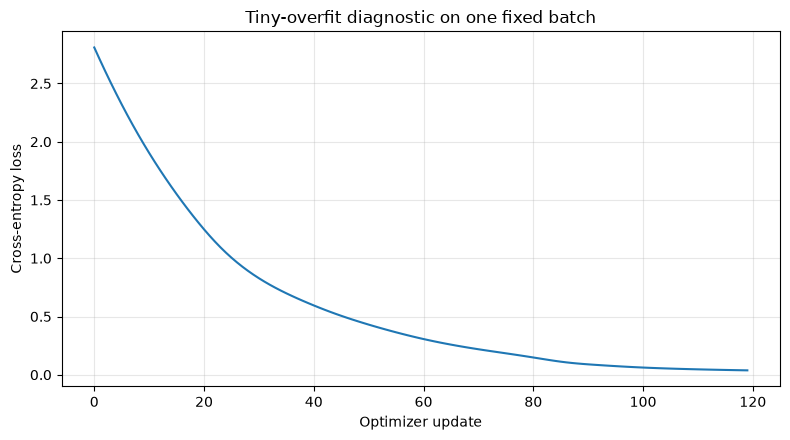

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4.5))
plt.plot(overfit_losses)
plt.xlabel("Optimizer update")
plt.ylabel("Cross-entropy loss")
plt.title("Tiny-overfit diagnostic on one fixed batch")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Inspect masking and architecture boundaries

A lower-triangular causal mask permits a position to use itself and earlier positions only.

The output layer weight shape must be `[vocabulary_size, embedding_dimension]`.

An input longer than the learned position table must fail clearly unless generation crops it first.

In [9]:
causal_mask = model.block.attention.causal_mask[0, 0].to(torch.int32)
expected_mask = torch.tril(torch.ones_like(causal_mask))
print("causal mask:")
print(causal_mask)
print("mask is lower triangular:", torch.equal(causal_mask, expected_mask))
print("output weight shape:", tuple(model.output_layer.weight.shape))
print("vocabulary size:", vocabulary_size)

too_long_input = torch.zeros(
    1, model.context_length + 1, dtype=torch.long, device=device
)
try:
    model(too_long_input)
except ValueError as error:
    print("context limit check:", error)

causal mask:
tensor([[1, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 1, 1]], dtype=torch.int32)
mask is lower triangular: True
output weight shape: (12, 16)
vocabulary size: 12
context limit check: input length must be within the model context limit.


## Recognize longer-run loss patterns

The following curves are synthetic diagnostic examples rather than results from the tiny model.

A shared four-panel figure keeps the patterns directly comparable.

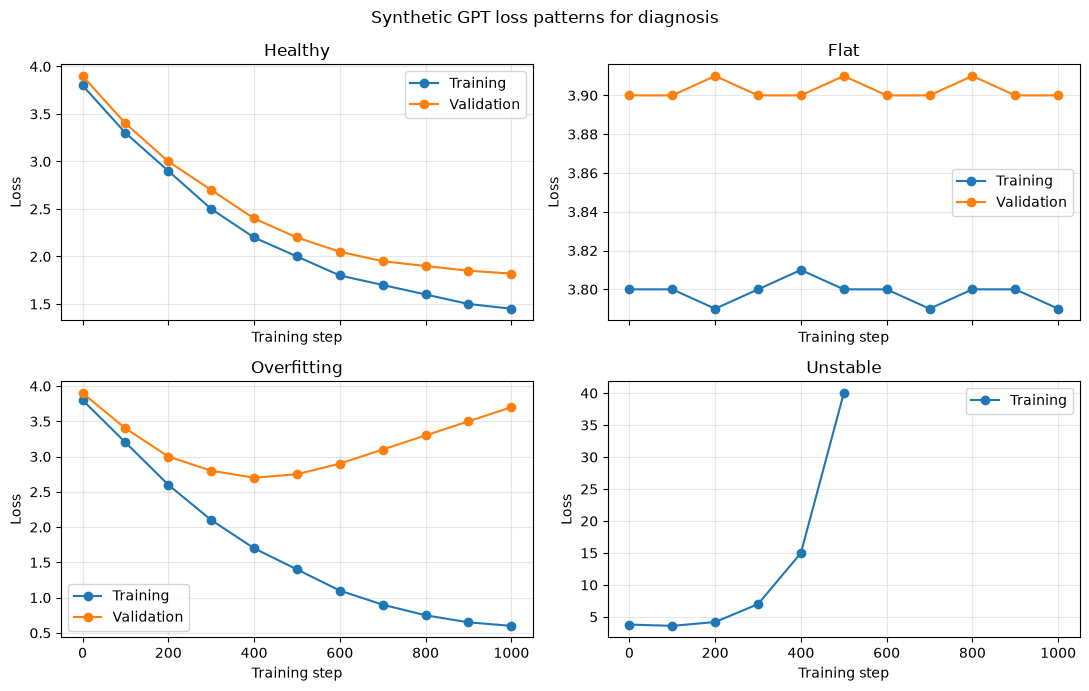

In [10]:
steps = list(range(0, 1001, 100))
loss_patterns = {
    "Healthy": (
        [3.8, 3.3, 2.9, 2.5, 2.2, 2.0, 1.8, 1.7, 1.6, 1.5, 1.45],
        [3.9, 3.4, 3.0, 2.7, 2.4, 2.2, 2.05, 1.95, 1.9, 1.85, 1.82],
    ),
    "Flat": (
        [3.8, 3.8, 3.79, 3.8, 3.81, 3.8, 3.8, 3.79, 3.8, 3.8, 3.79],
        [3.9, 3.9, 3.91, 3.9, 3.9, 3.91, 3.9, 3.9, 3.91, 3.9, 3.9],
    ),
    "Overfitting": (
        [3.8, 3.2, 2.6, 2.1, 1.7, 1.4, 1.1, 0.9, 0.75, 0.65, 0.6],
        [3.9, 3.4, 3.0, 2.8, 2.7, 2.75, 2.9, 3.1, 3.3, 3.5, 3.7],
    ),
    "Unstable": (
        [3.8, 3.6, 4.2, 7.0, 15.0, 40.0, float("nan"), *([float("nan")] * 4)],
        None,
    ),
}

figure, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for axis, (pattern_name, (training_values, validation_values)) in zip(
    axes.flat, loss_patterns.items(), strict=True
):
    axis.plot(steps, training_values, marker="o", label="Training")
    if validation_values is not None:
        axis.plot(steps, validation_values, marker="o", label="Validation")
    axis.set_title(pattern_name)
    axis.set_xlabel("Training step")
    axis.set_ylabel("Loss")
    axis.grid(alpha=0.3)
    axis.legend()

figure.suptitle("Synthetic GPT loss patterns for diagnosis")
figure.tight_layout()
plt.show()

## Map symptoms to focused checks

| Symptom | Check first |
|---|---|
| Flat training loss | Verify shift, gradients, learning rate, and that `optimizer.step()` changes parameters. |
| Non-finite loss | Stop updates, locate the first non-finite tensor, then inspect learning rate and arithmetic. |
| Suspiciously tiny training loss | Verify causal masking and train-validation leakage. |
| Large train-validation gap | Check split construction, evaluation mode, data size, and overfitting. |
| One-character or repetitive output | Inspect next-token probabilities and decoding settings before changing architecture. |
| Shape exception | Print the shape at each boundary nearest the exception. |
| Slow CPU run | Reduce context, batch, width, blocks, evaluation frequency, or generated sample length. |

## Diagnose slow CPU training

Attention logits have shape `[batch, heads, context, context]`, so their element count grows quadratically with context length.

Model width, block count, batch size, evaluation batches, and generation length also affect runtime.

Reduce one factor at a time and keep the data and correctness checks fixed while comparing.

Timing measurements are machine-dependent, so this notebook avoids storing volatile benchmark results.

## Separate training bugs from evaluation and decoding

Use `model.train()` for optimization and `model.eval()` with `torch.no_grad()` for validation and generation.

Wrong mode can make dropout-driven evaluation and samples noisy, but it does not explain every validation gap.

Repetition may come from greedy decoding, low temperature, overfitting, imbalanced data, or weak modeling.

Inspect the probability distribution and compare controlled seeds before assuming parameter collapse.

## Systematic checklist

Before a long run, confirm:

- decoded inputs and targets show the intended next-token shift;
- token tensors are nonempty `torch.long` values within the vocabulary;
- logits have `[batch, context, vocabulary]` shape and are finite;
- loss is finite;
- every expected parameter receives a finite gradient;
- one optimizer update changes parameter values;
- a fresh model can reduce loss on one fixed tiny batch;
- the causal mask and output layer dimensions are correct;
- training and evaluation modes are explicit; and
- validation batches are held out and reproducible.

## Common debugging mistakes

- Do not change many variables at once.
- Do not continue updating after a non-finite loss.
- Do not train for hundreds of steps before checking one batch.
- Do not treat gradient clipping as proof that the underlying problem is fixed.
- Do not run a tiny-overfit test on the only copy of a model you want to preserve.
- Do not assume low training loss is healthy when causal leakage is possible.
- Do not equate one generated sample with validation performance.
- Do not scale a model that cannot pass its basic invariants.

## Takeaways

Debug GPT training from the cheapest invariant toward the more expensive experiment.

Shapes, token ranges, target shifts, finite values, gradients, masks, and optimizer updates provide concrete evidence.

A tiny-overfit test separates basic optimization failure from broader generalization problems.

Loss curves and generation samples answer different questions and should be interpreted with controlled settings.

> Change one factor at a time, record what happened, and scale only after the small test passes.

## What comes next

With a reliable diagnostic workflow, later chapters can improve training without confusing optimization changes with hidden correctness bugs.

Learning-rate schedules, checkpointing, larger datasets, weight tying, and longer experiments all depend on these checks.